In [1]:
%pip -q install duckdb huggingface_hub


Note: you may need to restart the kernel to use updated packages.


In [1]:
import os, getpass

# CI and power users set HF_TOKEN in the environment; everyone else gets the safe prompt.
HF_TOKEN = os.environ.get('HF_TOKEN') or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')


In [2]:
import duckdb

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
TABLES = {
    'dim_clients':                f"read_parquet('{REL}/dim_clients.parquet')",
    'dim_content':                f"read_parquet('{REL}/dim_content.parquet')",
    'fact_daily':                 f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
    'fact_daily_sample':          f"read_parquet('{REL}/fact_content_daily_performance_sample.parquet')",
    'fact_query_90d':             f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}

for name, src in TABLES.items():
    n = con.sql(f'SELECT COUNT(*) FROM {src}').fetchone()[0]
    print(f'{name:22} {n:>12,} rows')


dim_clients                     104 rows
dim_content                 519,606 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

fact_daily               78,835,655 rows
fact_daily_sample        11,694,072 rows
fact_query_90d            2,414,248 rows


In [3]:
clients = con.sql(f"""
SELECT client_hash_id, access_profile, gsc_data_start, ga4_data_start
FROM {TABLES['dim_clients']}
LIMIT 10
""")

clients

┌─────────────────────────┬───────────────────────────────┬────────────────┬────────────────┐
│     client_hash_id      │        access_profile         │ gsc_data_start │ ga4_data_start │
│         varchar         │            varchar            │      date      │      date      │
├─────────────────────────┼───────────────────────────────┼────────────────┼────────────────┤
│ client_04660893ae39614a │ gsc_and_ga4                   │ NULL           │ 2026-05-22     │
│ client_05475c07ed21a83a │ no_search_or_analytics_access │ NULL           │ NULL           │
│ client_06d356715a8ff3b6 │ gsc_and_ga4                   │ 2026-04-10     │ 2026-04-06     │
│ client_0797ff3a1fc9a6a5 │ no_search_or_analytics_access │ 2025-11-05     │ NULL           │
│ client_08a6a72ff48e62c0 │ gsc_only                      │ 2025-09-24     │ NULL           │
│ client_08d2847f24cf89c1 │ gsc_and_ga4                   │ 2025-07-21     │ 2026-02-19     │
│ client_0b245132bb722950 │ gsc_and_ga4                   │ 

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [5]:
date_range = con.sql(f"""
SELECT
    MIN(report_date) AS start_date,
    MAX(report_date) AS end_date
FROM {TABLES['fact_daily_sample']}
""")

date_range

┌────────────┬────────────┐
│ start_date │  end_date  │
│    date    │    date    │
├────────────┼────────────┤
│ 2026-06-01 │ 2026-06-30 │
└────────────┴────────────┘

In [6]:
content_count = con.sql(f"""
SELECT COUNT(DISTINCT content_hash_id) AS total_pages
FROM {TABLES['fact_daily_sample']}
""")

content_count

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌─────────────┐
│ total_pages │
│    int64    │
├─────────────┤
│      409205 │
└─────────────┘

In [7]:
master = con.sql(f"""
SELECT

    f.report_date,
    f.client_hash_id,
    f.content_hash_id,

    f.gsc_impressions,
    f.gsc_clicks,
    f.gsc_avg_position,

    f.ga4_pageviews,
    f.ga4_sessions,
    f.ga4_users,
    f.ga4_engaged_sessions,

    d.content_created_date,
    d.content_updated_date,
    d.keyword_char_count,
    d.keyword_token_count,
    d.url_char_count

FROM {TABLES['fact_daily_sample']} f

LEFT JOIN {TABLES['dim_content']} d

ON f.content_hash_id = d.content_hash_id

LIMIT 50000
""").df()

master.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,report_date,client_hash_id,content_hash_id,gsc_impressions,gsc_clicks,gsc_avg_position,ga4_pageviews,ga4_sessions,ga4_users,ga4_engaged_sessions,content_created_date,content_updated_date,keyword_char_count,keyword_token_count,url_char_count
0,2026-06-02,client_f623b01661d4bfe4,content_575a1ed6e670a9a3,0,0,NaN,0,0,0,0,2025-08-07,2026-05-20,33,5,104
1,2026-06-02,client_f623b01661d4bfe4,content_22290552590d7529,0,0,NaN,0,0,0,0,2025-08-07,2026-05-20,41,8,101
2,2026-06-02,client_f623b01661d4bfe4,content_bc7ee2e19eb9ce58,0,0,NaN,0,0,0,0,2025-08-07,2026-05-20,47,7,103
3,2026-06-02,client_f623b01661d4bfe4,content_08bfdd6c0a86993f,6,0,5.833333,0,0,0,0,2025-08-07,2026-05-20,33,4,93
4,2026-06-02,client_f623b01661d4bfe4,content_4819593b7027a1c2,0,0,NaN,0,0,0,0,2025-08-07,2026-05-20,43,5,114


In [8]:
master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   report_date           50000 non-null  datetime64[us]
 1   client_hash_id        50000 non-null  object        
 2   content_hash_id       50000 non-null  object        
 3   gsc_impressions       50000 non-null  int64         
 4   gsc_clicks            50000 non-null  int64         
 5   gsc_avg_position      16045 non-null  float64       
 6   ga4_pageviews         46932 non-null  Int64         
 7   ga4_sessions          46932 non-null  Int64         
 8   ga4_users             46932 non-null  Int64         
 9   ga4_engaged_sessions  46932 non-null  Int64         
 10  content_created_date  50000 non-null  datetime64[us]
 11  content_updated_date  50000 non-null  datetime64[us]
 12  keyword_char_count    50000 non-null  int64         
 13  keyword_token_co

In [25]:
master.isnull().sum()

report_date                 0
client_hash_id              0
content_hash_id             0
gsc_impressions             0
gsc_clicks                  0
gsc_avg_position        33955
ga4_pageviews            3068
ga4_sessions             3068
ga4_users                3068
ga4_engaged_sessions     3068
content_created_date        0
content_updated_date        0
keyword_char_count          0
keyword_token_count         0
url_char_count              0
ctr                         0
content_age_days            0
days_since_update           0
refresh_needed              0
refresh_score               0
dtype: int64

Calculate CTR and Content Age

In [11]:
master["ctr"] = np.where(
    master["gsc_impressions"] > 0,
    master["gsc_clicks"] / master["gsc_impressions"],
    0
)

master["content_age_days"] = (
    master["report_date"] - master["content_created_date"]
).dt.days

master["days_since_update"] = (
    master["report_date"] - master["content_updated_date"]
).dt.days

Create a simple refresh label

In [12]:
master["refresh_needed"] = (
    (
        (master["gsc_impressions"] > 20) &
        (master["gsc_clicks"] == 0)
    )
    |
    (
        master["gsc_avg_position"] > 20
    )
    |
    (
        master["days_since_update"] > 90
    )
).astype(int)

In [14]:
#Check the class balance
master["refresh_needed"].value_counts()

refresh_needed
0    39213
1    10787
Name: count, dtype: int64

Select features

In [15]:
features = [
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "ga4_pageviews",
    "ga4_sessions",
    "ga4_users",
    "ga4_engaged_sessions",
    "keyword_char_count",
    "keyword_token_count",
    "url_char_count",
    "content_age_days",
    "days_since_update",
    "ctr"
]

df = master[features + ["refresh_needed"]].copy()

In [16]:
df = df.fillna(0)

In [26]:
df.shape

(50000, 14)

Split the Data

In [17]:
X = df.drop(columns=["refresh_needed"])
y = df["refresh_needed"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 40000
Testing samples: 10000


Train Random Forest

In [18]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
pred = rf.predict(X_test)

In [20]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7843
           1       1.00      1.00      1.00      2157

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



In [33]:
cm = confusion_matrix(y_test, pred)

print(cm)

[[7843    0]
 [   0 2157]]


In [22]:
importance = (
    pd.DataFrame({
        "Feature": X.columns,
        "Importance": rf.feature_importances_
    })
    .sort_values("Importance", ascending=False)
)

importance

,Feature,Importance
2,gsc_avg_position,0.289417
0,gsc_impressions,0.269040
11,days_since_update,0.236117
10,content_age_days,0.072952
1,gsc_clicks,0.038295
12,ctr,0.034958
4,ga4_sessions,0.013760
3,ga4_pageviews,0.013628
5,ga4_users,0.010414
8,keyword_token_count,0.007872


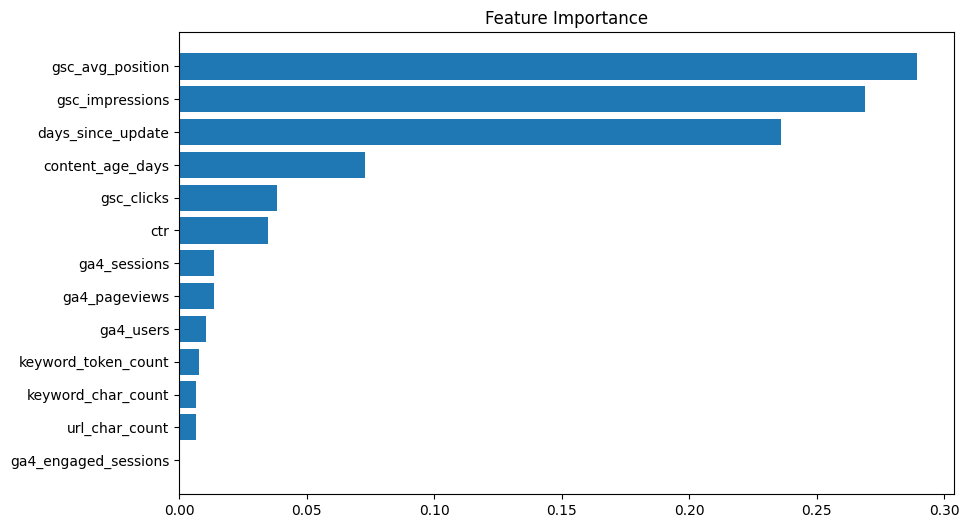

In [23]:
plt.figure(figsize=(10,6))
plt.barh(
    importance["Feature"],
    importance["Importance"]
)
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

In [27]:
master["refresh_score"] = rf.predict_proba(df[features])[:,1]

recommendations = (
    master[
        [
            "content_hash_id",
            "refresh_score",
            "gsc_clicks",
            "gsc_impressions",
            "gsc_avg_position",
            "days_since_update"
        ]
    ]
    .sort_values(
        "refresh_score",
        ascending=False
    )
)

recommendations.to_csv(
    "refresh_recommendations.csv",
    index=False
)

In [28]:
recommendations["priority"] = pd.cut(
    recommendations["refresh_score"],
    bins=[0, 0.4, 0.7, 1.0],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

In [29]:
recommendations.head(20)

,content_hash_id,refresh_score,gsc_clicks,gsc_impressions,gsc_avg_position,days_since_update,priority
14490,content_7bddc2288f6b0f4b,1.0,0,12,7.083333,97,High
19265,content_ee751ee89ff8e852,1.0,0,12,52.666667,97,High
19264,content_595cb8709686e9d3,1.0,0,0,NaN,97,High
38180,content_8000d654b5c7c9b3,1.0,0,24,9.583333,1,High
38179,content_b05323dcad7c4e46,1.0,0,94,7.329787,13,High
19262,content_7d4e85a9f673476a,1.0,0,0,NaN,97,High
19261,content_b459e4124bf77ce1,1.0,0,0,NaN,97,High
19260,content_986e75dbe89636ec,1.0,0,0,NaN,97,High
19259,content_45470e949c8363ea,1.0,0,14,11.285714,97,High
38171,content_b4bd76ef8a5a101c,1.0,0,24,10.416667,-27,High


In [30]:
recommendations.to_csv(
    "refresh_recommendations.csv",
    index=False
)

print("Saved as refresh_recommendations.csv")

Saved as refresh_recommendations.csv


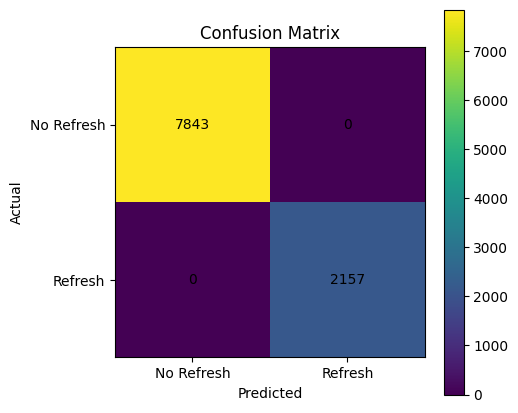

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0,1],["No Refresh","Refresh"])
plt.yticks([0,1],["No Refresh","Refresh"])

for i in range(2):
    for j in range(2):
        plt.text(j,i,str(cm[i,j]),
                 ha="center",
                 va="center")

plt.colorbar()
plt.show()

In [35]:
importance = (
    pd.DataFrame({
        "Feature": X.columns,
        "Importance": rf.feature_importances_
    })
    .sort_values("Importance", ascending=False)
)

importance

,Feature,Importance
2,gsc_avg_position,0.289417
0,gsc_impressions,0.269040
11,days_since_update,0.236117
10,content_age_days,0.072952
1,gsc_clicks,0.038295
12,ctr,0.034958
4,ga4_sessions,0.013760
3,ga4_pageviews,0.013628
5,ga4_users,0.010414
8,keyword_token_count,0.007872
